# Fase 1: EDA y Calidad de Datos
## Prueba Técnica - Análisis de Quejas ARL SURA

**Dataset:** BD_Quejas_Analitica.xlsx — Hoja: Incapacidad Temporal  
**Periodo:** Enero - Junio 2025  
**Objetivo:** Entender la estructura del dato, identificar problemas de calidad y obtener una visión inicial de los patrones antes de aplicar NLP.

---
### Estructura del notebook
1. Carga y primera inspección
2. Calidad de datos (nulos, duplicados, consistencia)
3. Análisis univariado (distribuciones)
4. Análisis bivariado / multivariado
5. Clientes recurrentes
6. Resumen de hallazgos y supuestos

In [ ]:
import sys, os
from pathlib import Path

EN_COLAB = 'google.colab' in sys.modules

if EN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # ── AJUSTA SI TU EXCEL ESTÁ EN OTRA RUTA DE DRIVE ─────────────────────────
    DATA_FILE = Path('/content/drive/MyDrive/sura/BD_Quejas_Analitica.xlsx')
    # ──────────────────────────────────────────────────────────────────────────

    OUT_BASE      = Path('/content/drive/MyDrive/sura')
    IMAGES_DIR    = OUT_BASE / 'resume' / 'images'
    MODELS_DIR    = OUT_BASE / 'src'
    DASHBOARD_DIR = OUT_BASE / 'dashboard' / 'public' / 'data'
    print('Entorno: Google Colab')
else:
    BASE_DIR      = Path('..').resolve()
    DATA_FILE     = BASE_DIR / 'req/BD_Quejas_Analitica.xlsx'
    IMAGES_DIR    = BASE_DIR / 'resume' / 'images'
    MODELS_DIR    = BASE_DIR / 'src'
    DASHBOARD_DIR = BASE_DIR / 'dashboard' / 'public' / 'data'
    print('Entorno: local')

IMAGES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

print(f'DATA_FILE : {DATA_FILE}  →  existe={DATA_FILE.exists()}')
print(f'Imágenes  : {IMAGES_DIR}')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Configuración visual
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")
sns.set_palette("Blues_d")
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 50)

RUTA_DATOS = Path('../req/BD_Quejas_Analitica.xlsx')
HOJA = 'Incapacidad Temporal'
print("Librerías cargadas ✓")

Librerías cargadas ✓


---
## 1. Carga y primera inspección

In [3]:
df = pd.read_excel(RUTA_DATOS, sheet_name=HOJA)

# Renombrar columnas a snake_case
df.columns = ['mes_apertura', 'descripcion', 'tipo', 'cliente', 'canal']

print(f"Filas: {len(df):,}  |  Columnas: {df.shape[1]}")
print(f"\nTipos de dato:")
print(df.dtypes)
df.head(3)

Filas: 1,841  |  Columnas: 5

Tipos de dato:
mes_apertura     int64
descripcion     object
tipo            object
cliente         object
canal           object
dtype: object


,mes_apertura,descripcion,tipo,cliente,canal
0,202501,USUARIA SOLICITA SABER EL ESTADO DE UNA INCAPACIDAD,QUEJA,JORGE MEJIA,LINEA DE ATENCIÓN
1,202501,BUEN DÍA CANDIALMENTE SOLICITAMOS INFORMACIÓN SOBRE EL ESTADO DE LA INCAPACIDAD RADIADA EL 10 DE DICIEMBRE 2024 CON ...,QUEJA,FERLEY GANAN,SEGUROSSURA.COM.CO
2,202501,"BUENAS DÍAS , QUIERO UN CERTIFICADO DE INCAPACIDADES Q VALLA DIRIGIDA A LA CAJA DE COMPENSACIÓN FAMILIAR COMFACOR, Y...",QUEJA,FABIAN LOPEZ,SEGUROSSURA.COM.CO


In [4]:
# Convertir mes a fecha real (primer día del mes)
df['fecha'] = pd.to_datetime(df['mes_apertura'].astype(str), format='%Y%m')
df['mes_nombre'] = df['fecha'].dt.strftime('%b %Y')  # ej: "Ene 2025"

# Longitud de descripción
df['len_descripcion'] = df['descripcion'].fillna('').str.len()

print("Columnas finales:", df.columns.tolist())
df[['mes_apertura', 'fecha', 'cliente', 'canal', 'len_descripcion']].head(5)

Columnas finales: ['mes_apertura', 'descripcion', 'tipo', 'cliente', 'canal', 'fecha', 'mes_nombre', 'len_descripcion']


,mes_apertura,fecha,cliente,canal,len_descripcion
0,202501,2025-01-01,JORGE MEJIA,LINEA DE ATENCIÓN,51
1,202501,2025-01-01,FERLEY GANAN,SEGUROSSURA.COM.CO,404
2,202501,2025-01-01,FABIAN LOPEZ,SEGUROSSURA.COM.CO,594
3,202501,2025-01-01,SAMAN INVERSIONES S.A.S.,LINEA DE ATENCIÓN,50
4,202501,2025-01-01,JOSE CHAVERRA,SEGUROSSURA.COM.CO,849


---
## 2. Calidad de datos

In [5]:
# --- 2.1 Nulos y vacíos ---
nulos = df[['mes_apertura', 'descripcion', 'tipo', 'cliente', 'canal']].isnull().sum()
vacios = (df[['mes_apertura', 'descripcion', 'tipo', 'cliente', 'canal']] == '').sum()

calidad = pd.DataFrame({'nulos': nulos, 'vacíos': vacios})
calidad['total_problemas'] = calidad['nulos'] + calidad['vacíos']
calidad['% sobre total'] = (calidad['total_problemas'] / len(df) * 100).round(2)

print("=== Nulos y vacíos por columna ===")
print(calidad)

# Ver las filas con descripción nula
print(f"\n--- Registros con descripción nula ({nulos['descripcion']}) ---")
df[df['descripcion'].isnull()][['mes_apertura', 'cliente', 'canal']]

=== Nulos y vacíos por columna ===
              nulos  vacíos  total_problemas  % sobre total
mes_apertura      0       0                0           0.00
descripcion       2       0                2           0.11
tipo              0       0                0           0.00
cliente           0       0                0           0.00
canal             0       0                0           0.00

--- Registros con descripción nula (2) ---


,mes_apertura,cliente,canal
584,202502,CARLOS SANTACRUZ,SEGUROSSURA.COM.CO
1017,202504,RACORES Y COMPONENTES METALMECANICOS SAS,LINEA DE ATENCIÓN


In [6]:
# --- 2.2 Duplicados ---
# Duplicado exacto (mismo cliente + descripción + mes)
dup_exactos = df.duplicated(subset=['cliente', 'descripcion', 'mes_apertura']).sum()

# Misma descripción, distinto cliente (texto genérico de línea de atención)
dup_desc = df.duplicated(subset=['descripcion'], keep=False)
dup_desc_count = dup_desc.sum()

print(f"Duplicados exactos (cliente + descripción + mes): {dup_exactos}")
print(f"Descripciones repetidas entre distintos registros: {dup_desc_count}")
print()

# Ver ejemplos de descripciones repetidas (típico de línea de atención con plantilla)
desc_repetidas = df[dup_desc].groupby('descripcion')['cliente'].agg(['count', list]).sort_values('count', ascending=False).head(5)
desc_repetidas.index = desc_repetidas.index.str[:80]
print("Top 5 descripciones repetidas:")
print(desc_repetidas)

Duplicados exactos (cliente + descripción + mes): 21
Descripciones repetidas entre distintos registros: 89

Top 5 descripciones repetidas:
                                                                                       count  \
descripcion                                                                                    
ANEXO CARTA CON DETALLE DE LA QUEJA                                                        9   
CASO SUPERSALUD\n\nDATOS DEL AFECTADO\nADOLFO  NUÑEZ ESCALANTE\nCC : 73100705\n605652      7   
QUIERO VALIDAR EL ESTADO DE UNA INCAPACIDAD                                                5   
USUARIO SE COMUNICA POR QUE DESEA VALIDAR EL ESTADO DE  SU INCAPACIDAD                     4   
DERECHO DE PETICION                                                                        4   

                                                                                                                                                                                            

In [7]:
# --- 2.3 Consistencia de nombres de clientes ---
# Normalizar para detectar variantes del mismo cliente
df['cliente_norm'] = (df['cliente']
    .str.upper()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.replace(r'[.,;]', '', regex=True)
)

n_clientes_raw  = df['cliente'].nunique()
n_clientes_norm = df['cliente_norm'].nunique()

print(f"Clientes únicos (original):   {n_clientes_raw:,}")
print(f"Clientes únicos (normalizado): {n_clientes_norm:,}")
print(f"Variantes colapsadas: {n_clientes_raw - n_clientes_norm}")
print()

# Detectar variantes probables (mismo inicio, longitud similar)
# Se muestra solo si hay diferencia
if n_clientes_raw != n_clientes_norm:
    diff = set(df['cliente'].str.upper().str.strip()) - set(df['cliente_norm'])
    print("Ejemplos de variantes detectadas:", list(diff)[:10])
else:
    print("No se detectaron variantes de nombres.")

Clientes únicos (original):   1,334
Clientes únicos (normalizado): 1,334
Variantes colapsadas: 0

No se detectaron variantes de nombres.


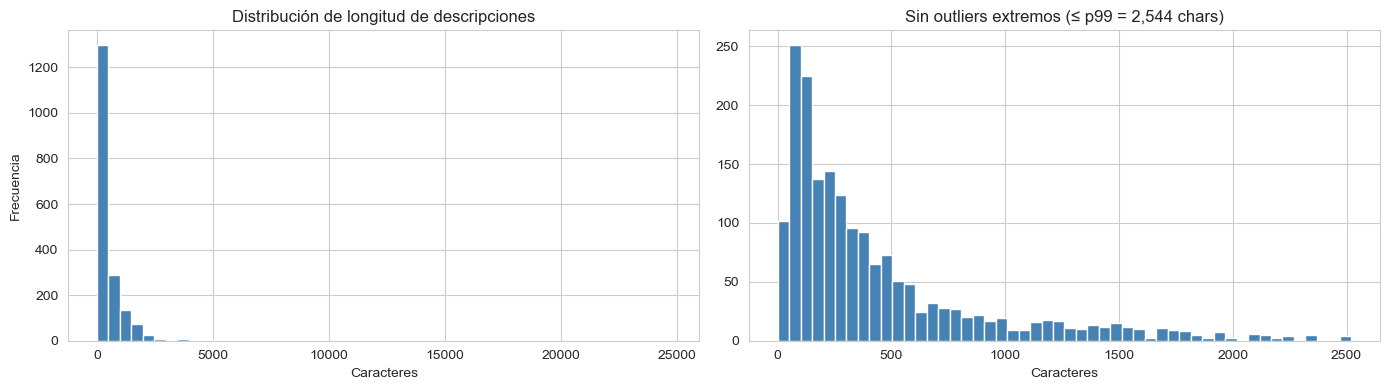

count     1841
mean       490
std        796
min          0
25%        124
50%        273
75%        575
max      24744

Registros con descripción muy corta (≤20 chars): 17
Registros con descripción muy larga (≥5,000 chars): 2


In [8]:
# --- 2.4 Distribución de longitud de descripciones ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma completo
axes[0].hist(df['len_descripcion'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de longitud de descripciones')
axes[0].set_xlabel('Caracteres')
axes[0].set_ylabel('Frecuencia')

# Sin outliers extremos (percentil 99)
p99 = df['len_descripcion'].quantile(0.99)
axes[1].hist(df[df['len_descripcion'] <= p99]['len_descripcion'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title(f'Sin outliers extremos (≤ p99 = {int(p99):,} chars)')
axes[1].set_xlabel('Caracteres')

plt.tight_layout()
plt.show()
plt.savefig('../resume/images/01_longitud_descripciones.png', dpi=150, bbox_inches='tight')

print(df['len_descripcion'].describe().round(0).astype(int).to_string())
print(f"\nRegistros con descripción muy corta (≤20 chars): {(df['len_descripcion'] <= 20).sum()}")
print(f"Registros con descripción muy larga (≥5,000 chars): {(df['len_descripcion'] >= 5000).sum()}")

---
## 3. Análisis univariado

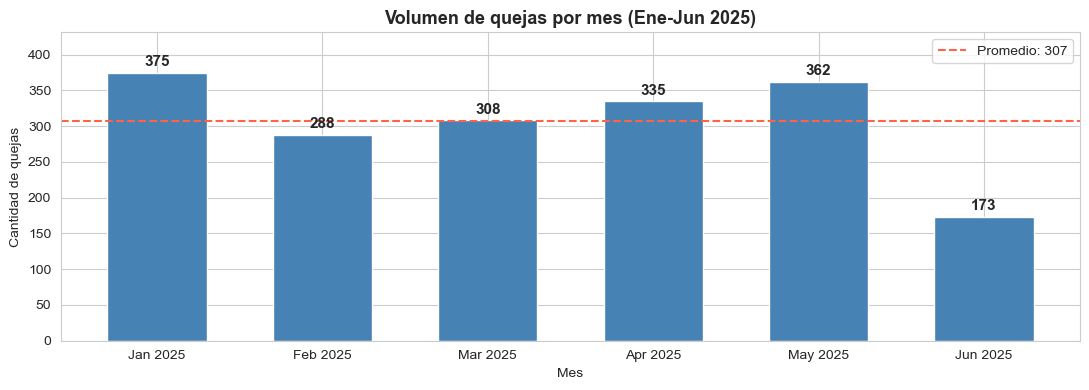

mes_label  quejas
 Jan 2025     375
 Feb 2025     288
 Mar 2025     308
 Apr 2025     335
 May 2025     362
 Jun 2025     173

Nota: Junio (173) probablemente es mes incompleto en la extracción.


In [9]:
# --- 3.1 Tendencia temporal de quejas por mes ---
quejas_mes = df.groupby('fecha').size().reset_index(name='quejas')
quejas_mes['mes_label'] = quejas_mes['fecha'].dt.strftime('%b %Y')

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(quejas_mes['mes_label'], quejas_mes['quejas'], color='steelblue', edgecolor='white', width=0.6)

# Etiquetas de valor
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Volumen de quejas por mes (Ene-Jun 2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Cantidad de quejas')
ax.set_ylim(0, quejas_mes['quejas'].max() * 1.15)

# Línea de promedio
promedio = quejas_mes['quejas'].mean()
ax.axhline(promedio, color='tomato', linestyle='--', linewidth=1.5, label=f'Promedio: {promedio:.0f}')
ax.legend()

plt.tight_layout()
plt.show()
plt.savefig('../resume/images/01_volumen_mensual.png', dpi=150, bbox_inches='tight')

print(quejas_mes[['mes_label', 'quejas']].to_string(index=False))
print(f"\nNota: Junio (173) probablemente es mes incompleto en la extracción.")

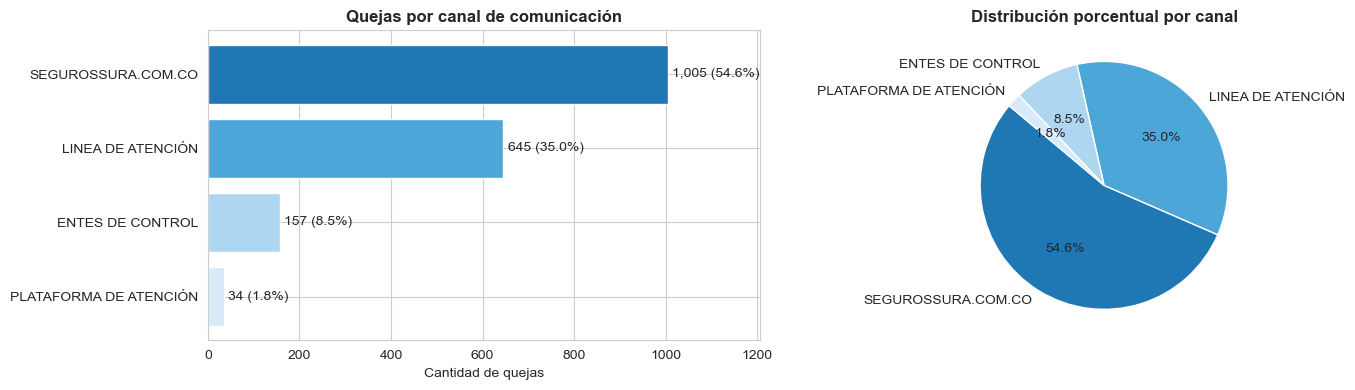

In [10]:
# --- 3.2 Distribución por canal ---
canal_counts = df['canal'].value_counts()
canal_pct    = (canal_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Barras
colores = ['#1f77b4', '#4da6d8', '#aed6f1', '#d6eaf8']
axes[0].barh(canal_counts.index, canal_counts.values, color=colores)
for i, (v, p) in enumerate(zip(canal_counts.values, canal_pct.values)):
    axes[0].text(v + 10, i, f'{v:,} ({p}%)', va='center', fontsize=10)
axes[0].set_title('Quejas por canal de comunicación', fontweight='bold')
axes[0].set_xlabel('Cantidad de quejas')
axes[0].invert_yaxis()
axes[0].set_xlim(0, canal_counts.max() * 1.2)

# Pie
wedges, texts, autotexts = axes[1].pie(
    canal_counts.values,
    labels=canal_counts.index,
    autopct='%1.1f%%',
    colors=colores,
    startangle=140
)
axes[1].set_title('Distribución porcentual por canal', fontweight='bold')

plt.tight_layout()
plt.show()
plt.savefig('../resume/images/01_distribucion_canales.png', dpi=150, bbox_inches='tight')

---
## 4. Análisis bivariado / multivariado

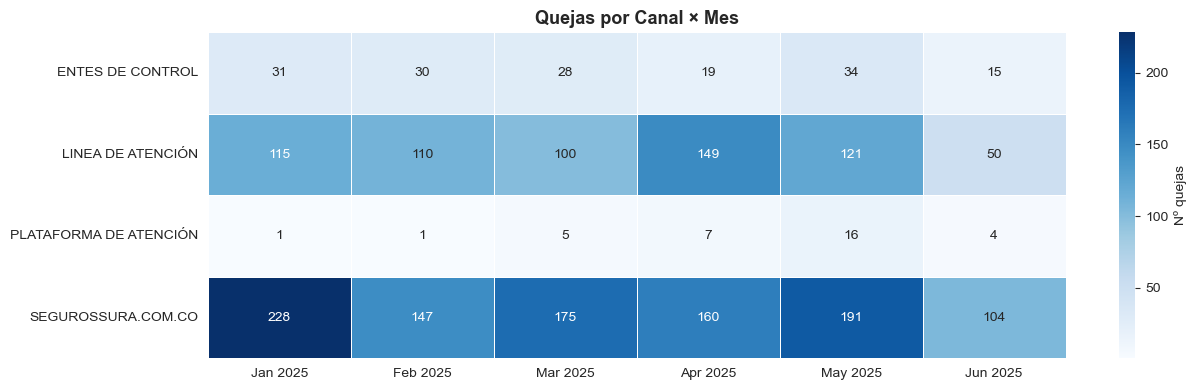

In [11]:
# --- 4.1 Canal × Mes (heatmap de volumen) ---
pivot_canal_mes = df.pivot_table(index='canal', columns='mes_nombre', values='tipo', aggfunc='count', fill_value=0)

# Reordenar columnas cronológicamente
orden_meses = df.sort_values('fecha')['mes_nombre'].unique()
pivot_canal_mes = pivot_canal_mes[orden_meses]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot_canal_mes, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            cbar_kws={'label': 'Nº quejas'}, ax=ax)
ax.set_title('Quejas por Canal × Mes', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()
plt.savefig('../resume/images/01_heatmap_canal_mes.png', dpi=150, bbox_inches='tight')

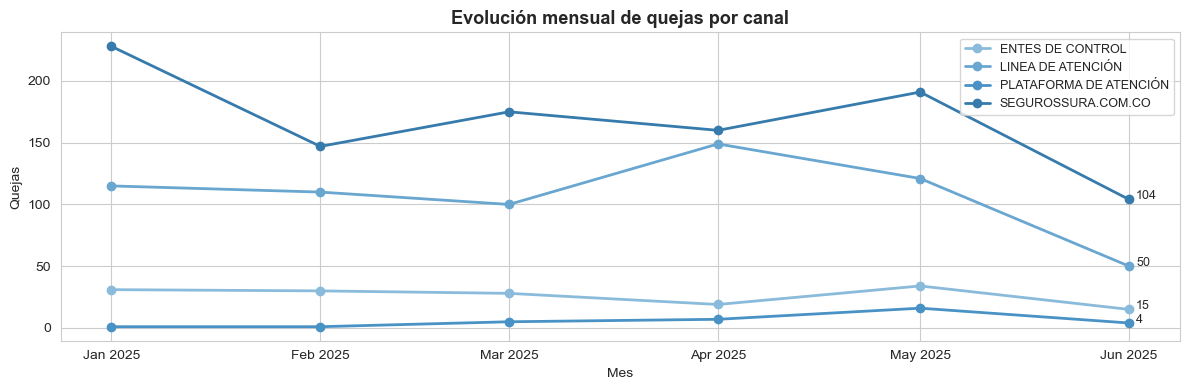

In [12]:
# --- 4.2 Evolución por canal (líneas) ---
evol = df.groupby(['fecha', 'canal']).size().reset_index(name='quejas')

fig, ax = plt.subplots(figsize=(12, 4))
for canal, grupo in evol.groupby('canal'):
    ax.plot(grupo['fecha'], grupo['quejas'], marker='o', linewidth=2, label=canal)
    # Etiqueta en último punto
    ultimo = grupo.iloc[-1]
    ax.annotate(f"{int(ultimo['quejas'])}", xy=(ultimo['fecha'], ultimo['quejas']),
                xytext=(5, 0), textcoords='offset points', fontsize=9)

ax.set_title('Evolución mensual de quejas por canal', fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Quejas')
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()
plt.savefig('../resume/images/01_evolucion_canal.png', dpi=150, bbox_inches='tight')

---
## 5. Análisis de clientes recurrentes

In [13]:
# --- 5.1 Frecuencia de quejas por cliente ---
freq_cliente = df.groupby('cliente_norm').size().reset_index(name='n_quejas')
freq_cliente = freq_cliente.sort_values('n_quejas', ascending=False)

# Clasificar: recurrente si tiene >1 queja
df['es_recurrente'] = df['cliente_norm'].map(
    freq_cliente.set_index('cliente_norm')['n_quejas'] > 1
)

total_recurrentes = (freq_cliente['n_quejas'] > 1).sum()
quejas_de_recurrentes = freq_cliente[freq_cliente['n_quejas'] > 1]['n_quejas'].sum()

print(f"Clientes únicos:               {len(freq_cliente):,}")
print(f"Clientes recurrentes (>1 queja): {total_recurrentes:,} ({total_recurrentes/len(freq_cliente)*100:.1f}%)")
print(f"Quejas generadas por recurrentes: {quejas_de_recurrentes:,} ({quejas_de_recurrentes/len(df)*100:.1f}% del total)")
print()
print("Top 15 clientes con más quejas:")
print(freq_cliente.head(15).to_string(index=False))

Clientes únicos:               1,334
Clientes recurrentes (>1 queja): 277 (20.8%)
Quejas generadas por recurrentes: 784 (42.6% del total)

Top 15 clientes con más quejas:
                                                         cliente_norm  n_quejas
                                                        ALTIPAL S A S        11
                                                         ADOLFO NUÑEZ        11
                             AGRICOLA EL RETIRO SAS EN REORGANIZACION        10
                                                        JORGE GIRALDO         9
                                                        JOSE GARAVITO         8
                                                   MG CONSULTORES SAS         7
                             SOLUCIONES LABORALES HORIZONTE SA SLH SA         7
                                                          ANA JIMENEZ         6
                                  COMUNICACION CELULAR S A COMCEL S A         6
                             

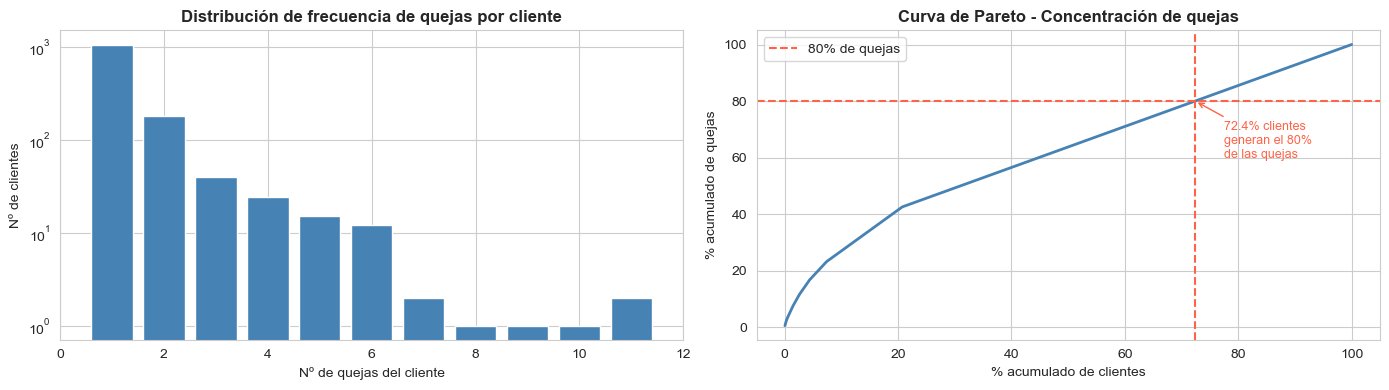

In [14]:
# --- 5.2 Distribución de frecuencia (cuántos clientes tienen 1, 2, 3... quejas) ---
dist_freq = freq_cliente['n_quejas'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribución completa (escala log por la larga cola)
axes[0].bar(dist_freq.index, dist_freq.values, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de frecuencia de quejas por cliente', fontweight='bold')
axes[0].set_xlabel('Nº de quejas del cliente')
axes[0].set_ylabel('Nº de clientes')
axes[0].set_yscale('log')
axes[0].set_xlim(0, dist_freq.index.max() + 1)

# Curva de Pareto
freq_sorted = freq_cliente.sort_values('n_quejas', ascending=False)
freq_sorted['cum_quejas'] = freq_sorted['n_quejas'].cumsum()
freq_sorted['cum_pct_quejas'] = freq_sorted['cum_quejas'] / freq_sorted['n_quejas'].sum() * 100
freq_sorted['cum_pct_clientes'] = np.arange(1, len(freq_sorted)+1) / len(freq_sorted) * 100

axes[1].plot(freq_sorted['cum_pct_clientes'], freq_sorted['cum_pct_quejas'], color='steelblue', linewidth=2)
axes[1].axhline(80, color='tomato', linestyle='--', label='80% de quejas')
# Encontrar el % de clientes que genera el 80% de quejas
x_80 = freq_sorted.loc[freq_sorted['cum_pct_quejas'] >= 80, 'cum_pct_clientes'].iloc[0]
axes[1].axvline(x_80, color='tomato', linestyle='--')
axes[1].annotate(f'{x_80:.1f}% clientes\ngeneran el 80%\nde las quejas',
                 xy=(x_80, 80), xytext=(x_80+5, 60), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='tomato'), color='tomato')
axes[1].set_title('Curva de Pareto - Concentración de quejas', fontweight='bold')
axes[1].set_xlabel('% acumulado de clientes')
axes[1].set_ylabel('% acumulado de quejas')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.savefig('../resume/images/01_frecuencia_clientes.png', dpi=150, bbox_inches='tight')

Clientes recurrentes que usaron Entes de Control en ≥1 queja: 47 (17.0%)



/var/folders/9h/nlwl71sd66l0x7jrqftb0h3w0000gn/T/ipykernel_10334/3057550172.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  comp_pct = comp_canal.groupby('es_recurrente').apply(


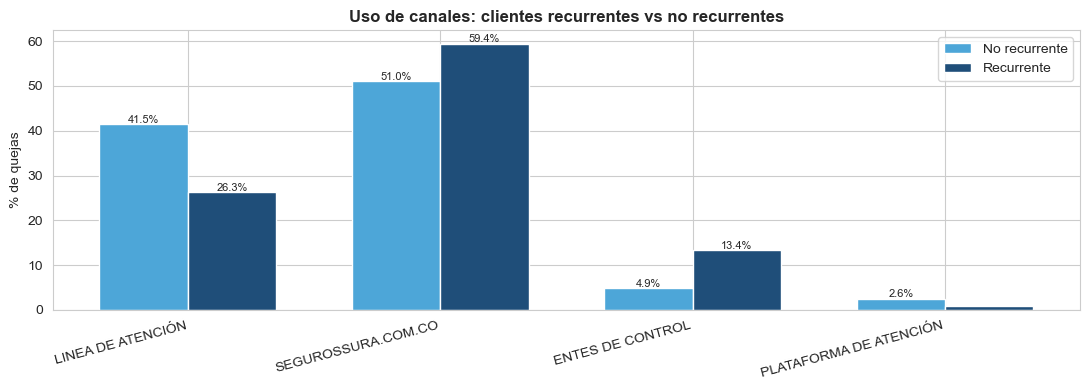

In [15]:
# --- 5.3 Recurrentes: ¿usan el mismo canal o escalan? ---
recurrentes = df[df['es_recurrente']]

# Canal preferido vs canal de escalamiento
rec_canal = recurrentes.groupby(['cliente_norm', 'canal']).size().reset_index(name='n')
rec_canal_pivot = rec_canal.pivot_table(index='cliente_norm', columns='canal', values='n', fill_value=0)

# ¿Cuántos recurrentes usaron Entes de Control en alguna de sus quejas?
uso_entes = recurrentes.groupby('cliente_norm')['canal'].apply(
    lambda x: 'ENTES DE CONTROL' in x.values
)
pct_entes = uso_entes.mean() * 100

print(f"Clientes recurrentes que usaron Entes de Control en ≥1 queja: {uso_entes.sum()} ({pct_entes:.1f}%)")
print()

# Distribución de canales usados por recurrentes vs no recurrentes
comp_canal = df.groupby(['es_recurrente', 'canal']).size().reset_index(name='n')
comp_canal['es_recurrente'] = comp_canal['es_recurrente'].map({True: 'Recurrente', False: 'No recurrente'})
comp_pct = comp_canal.groupby('es_recurrente').apply(
    lambda x: x.assign(pct=x['n']/x['n'].sum()*100)
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 4))
canales = df['canal'].unique()
x = np.arange(len(canales))
width = 0.35

for i, tipo in enumerate(['No recurrente', 'Recurrente']):
    vals = comp_pct[comp_pct['es_recurrente'] == tipo].set_index('canal')['pct'].reindex(canales).fillna(0)
    bars = ax.bar(x + i*width, vals, width, label=tipo, color=['#4da6d8', '#1f4e79'][i])
    for bar in bars:
        h = bar.get_height()
        if h > 1:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}%', ha='center', fontsize=8)

ax.set_xticks(x + width/2)
ax.set_xticklabels(canales, rotation=15, ha='right')
ax.set_title('Uso de canales: clientes recurrentes vs no recurrentes', fontweight='bold')
ax.set_ylabel('% de quejas')
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig('../resume/images/01_canales_recurrentes.png', dpi=150, bbox_inches='tight')

---
## 6. Resumen de hallazgos y supuestos

### Hallazgos de calidad
- **2 registros** con descripción nula (0.1%) → se excluyen del análisis NLP
- **Columna Tipo** constante = "QUEJA" → no aporta como feature; toda la información útil está en el texto libre
- Nombres de clientes pueden tener variantes menores (espacios, puntuación)

### Hallazgos descriptivos
- **Tendencia temporal**: volumen relativamente estable (~300-375/mes); **Junio tiene solo 173**, asumimos datos incompletos
- **Canal dominante**: SEGUROSSURA.COM.CO concentra el 54.6% de quejas; ENTES DE CONTROL es el 8.5% → señal de insatisfacción crítica
- **Clientes recurrentes**: 277 clientes (20.7%) generan múltiples quejas; la curva de Pareto dirá cuánta concentración existe

### Supuestos para siguientes fases
1. Junio 2025 = mes incompleto → se normalizará por días hábiles si se necesita comparar
2. Las descripciones de la Línea de Atención suelen ser más cortas y estandarizadas (ej. "USUARIO SOLICITA SABER EL ESTADO DE SU INCAPACIDAD")
3. Canal ENTES DE CONTROL = proxy de insatisfacción grave → se usará como variable Y en el modelo ML
4. Las descripciones largas (>5,000 chars) pueden contener múltiples radicados o recobros → se tratarán como caso especial en el NLP

### Próximo paso: Notebook 02 — NLP y extracción de temas